# Scenario-based Forecasting

You already saw how to add regressors in [Events and Holidays](15_events_and_holidays.ipynb). In Scenario-based forecasting, the regressor is something the business *controls*, so the forecasts unfold based on those decisions.

In this lab you will:

- fit a Prophet model with a controllable marketing-spend regressor;
- construct Baseline and Aggressive marketing scenarios; and
- report projected sales with uncertainty intervals for each scenario.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from prophet import Prophet
from prophet.utilities import regressor_coefficients

# Docs: https://facebook.github.io/prophet/docs/quick_start.html
#       https://pandas.pydata.org/docs/
#       https://seaborn.pydata.org/
sns.set_theme(style="whitegrid")

LESSON_DIR = Path().resolve()
DATA_DIR = LESSON_DIR.parent / "data"

Importing plotly failed. Interactive plots will not work.


## Load and explore the data

We use a **simulated retailer**: monthly numbers for one shop, generated so marketing and price effects are clear:

In [2]:
retail = pd.read_csv(
    DATA_DIR / "retail_marketing.csv",
    parse_dates=["date"],  # month-start timestamps for the time axis
)
retail.head()

,date,sales,marketing_spend,avg_price
0,2018-01-01,227.76,41.22,26.13
1,2018-02-01,230.21,39.84,26.92
2,2018-03-01,251.90,49.93,27.35
3,2018-04-01,245.73,51.76,28.34
4,2018-05-01,202.57,39.12,28.66


Let's first explain what each column mean:

| Column | Meaning |
|---|---|
| `date` | First day of the month (the time stamp for that month’s totals). |
| `sales` | Total revenue that month, in thousands of dollars — what we will forecast. |
| `marketing_spend` | Money spent on ads/promotions that month, in thousands of dollars. Management chooses this (a controllable driver). |
| `avg_price` | Average price paid per item sold that month (USD). If the shop sells many products, this is the blended “how expensive were things?” figure — also something management can change (raise prices or discount). |

`sales` is the target. `marketing_spend` and `avg_price` are **exogenous** drivers (i.e., external variables) we can turn into scenarios.


In [3]:
retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             72 non-null     datetime64[us]
 1   sales            72 non-null     float64       
 2   marketing_spend  72 non-null     float64       
 3   avg_price        72 non-null     float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 2.4 KB


### Sales over time

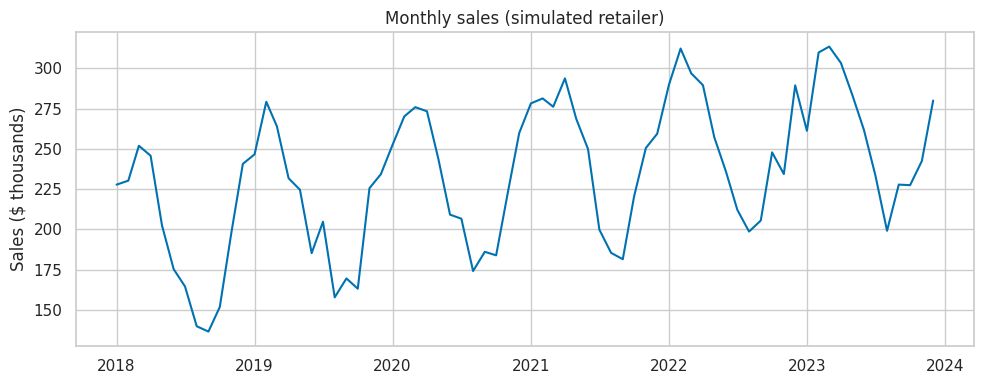

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    data=retail,
    x="date",
    y="sales",
    ax=ax,
    color="#0072B2",
    linewidth=1.5,
)
ax.set(
    title="Monthly sales (simulated retailer)",
    xlabel="",
    ylabel="Sales ($ thousands)",
)
fig.tight_layout()

### Sales vs marketing spend

Let's check first if `sales` and `marketing_spend` are actually correlated.

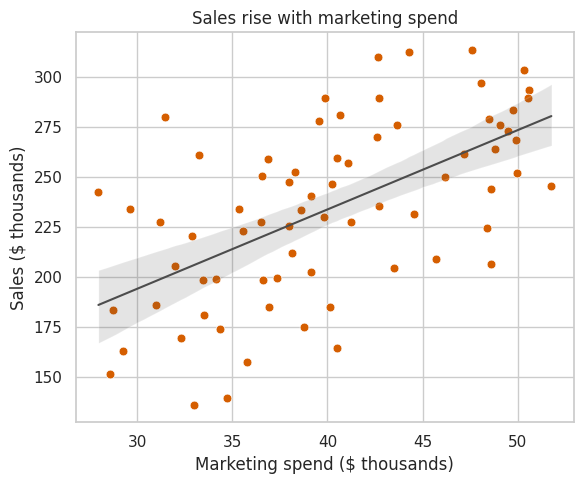

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(
    data=retail,
    x="marketing_spend",
    y="sales",
    ax=ax,
    color="#D55E00",
    s=40,
)
sns.regplot(
    data=retail,
    x="marketing_spend",
    y="sales",
    ax=ax,
    scatter=False,  # keep the scatter from sns.scatterplot above
    color="0.3",
    line_kws={"linewidth": 1.5},
)
ax.set(
    title="Sales rise with marketing spend",
    xlabel="Marketing spend ($ thousands)",
    ylabel="Sales ($ thousands)",
)
fig.tight_layout()

## Prepare data for Prophet

Prophet expects:

- `ds` — the datestamp;
- `y` — the series to forecast;
- plus any extra regressor columns (here `marketing_spend`).

In [6]:
df = retail.rename(
    columns={
        "date": "ds",  # Prophet's required date column
        "sales": "y",  # the target we will forecast
    }
)
# Keep marketing_spend (and avg_price for the later exercise).
df = df[["ds", "y", "marketing_spend", "avg_price"]].copy()
df.tail()

,ds,y,marketing_spend,avg_price
67,2023-08-01,199.09,34.15,31.80
68,2023-09-01,227.78,36.50,30.28
69,2023-10-01,227.44,31.23,28.98
70,2023-11-01,242.40,27.97,27.80
71,2023-12-01,280.03,31.47,28.23


## Fit a Prophet model with a marketing regressor

- `add_regressor` turns Prophet into a multivariate model: trend + seasonality + a coefficient on `marketing_spend`.
- Monthly data does not need a weekly seasonality component, so we turn that off.

In [7]:
m = Prophet(
    weekly_seasonality=False,  # monthly series: no day-of-week pattern
    yearly_seasonality=True,   # keep the Nov/Dec retail peak
)
m.add_regressor("marketing_spend")
m.fit(df)

20:55:37 - cmdstanpy - INFO - Chain [1] start processing
20:55:37 - cmdstanpy - INFO - Chain [1] done processing


Inspect how much each unit of marketing spend moves the forecast:

In [8]:
coefs = regressor_coefficients(m)
coefs

,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,marketing_spend,additive,40.088194,3.12731,3.12731,3.12731


A positive `coef` means higher future marketing spend raises projected sales — exactly what makes marketing scenarios diverge.

## The key step: future regressor values are scenarios

`make_future_dataframe` creates the dates, but it does **not** fill in `marketing_spend`. We must supply that column ourselves. Whatever values we choose define the scenario.

In [9]:
HORIZON_MONTHS = 12

future = m.make_future_dataframe(
    periods=HORIZON_MONTHS,
    freq="MS",  # month starts, matching the historical grain
)
future.tail(HORIZON_MONTHS + 2)

,ds
70,2023-11-01
71,2023-12-01
72,2024-01-01
73,2024-02-01
74,2024-03-01
75,2024-04-01
76,2024-05-01
77,2024-06-01
78,2024-07-01
79,2024-08-01


Notice there is no `marketing_spend` column yet. Calling `m.predict(future)` now would fail.

Prophet's docs require the extra regressor on **every** row of the future frame (history and horizon). The usual pattern is:

1. `make_future_dataframe` for the dates;
2. bring over observed regressor values for historical dates (e.g. with a merge);
3. fill the remaining (future) rows with your scenario assumptions;
4. call `predict`.


In [20]:
def forecast_scenario(
    model: Prophet,
    future_spend: pd.Series | np.ndarray | list[float],
    *,
    periods: int = HORIZON_MONTHS,
    freq: str = "MS",
) -> pd.DataFrame:
    """Predict under a marketing-spend scenario (Prophet extra-regressor pattern).

    Follows the docs: build a future frame, attach the regressor for all dates,
    then `predict`. Historical spend comes from `model.history`; only the
    forecast horizon is filled with `future_spend`.
    """
    # 1. Dates for history + horizon (Prophet helper)
    future = model.make_future_dataframe(
        periods=periods,
        freq=freq,
    )
    # 2. Observed regressor values for historical dates
    future = future.merge(
        model.history[["ds", "marketing_spend"]],
        on="ds",
        how="left",
    )
    # 3. Scenario assumptions for dates that still lack spend
    is_forecast = future["marketing_spend"].isna()
    future.loc[is_forecast, "marketing_spend"] = list(future_spend)
    # 4. Predict as usual
    return model.predict(future)


## Worked scenarios: Baseline vs Aggressive

We compare two 12-month marketing plans:

| Scenario | Assumption |
|---|---|
| **Baseline** | Hold marketing spend at the recent average (status quo). |
| **Aggressive** | Raise every month's spend by 40% relative to Baseline. |

In [21]:
# Recent average spend is a natural "do nothing different" baseline.
recent_avg_spend = df["marketing_spend"].tail(12).mean()

baseline_spend = np.full(HORIZON_MONTHS, recent_avg_spend)
aggressive_spend = baseline_spend * 1.40  # +40% marketing budget

print(f"Baseline monthly spend:   ${recent_avg_spend:,.1f}k")
print(f"Aggressive monthly spend: ${recent_avg_spend * 1.40:,.1f}k")

Baseline monthly spend:   $39.2k
Aggressive monthly spend: $54.9k


In [22]:
fc_baseline = forecast_scenario(
    model=m,
    future_spend=baseline_spend,
)
fc_aggressive = forecast_scenario(
    model=m,
    future_spend=aggressive_spend,
)

fc_baseline[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(HORIZON_MONTHS)


,ds,yhat,yhat_lower,yhat_upper
72,2024-01-01,300.957167,293.390861,308.342331
73,2024-02-01,312.898927,305.614192,320.671228
74,2024-03-01,293.188759,285.651891,300.598448
75,2024-04-01,291.465620,284.015443,299.175054
76,2024-05-01,270.162118,262.595637,277.723838
77,2024-06-01,248.894892,241.273116,255.928227
78,2024-07-01,228.917419,221.782873,236.612970
79,2024-08-01,237.554857,229.655389,245.135589
80,2024-09-01,250.154449,242.818405,257.727764
81,2024-10-01,272.751529,264.834919,280.545454


### Overlay the two forecasts

Plot the last two years of history plus both scenario forecasts (with uncertainty bands) so the gap is easy to see.

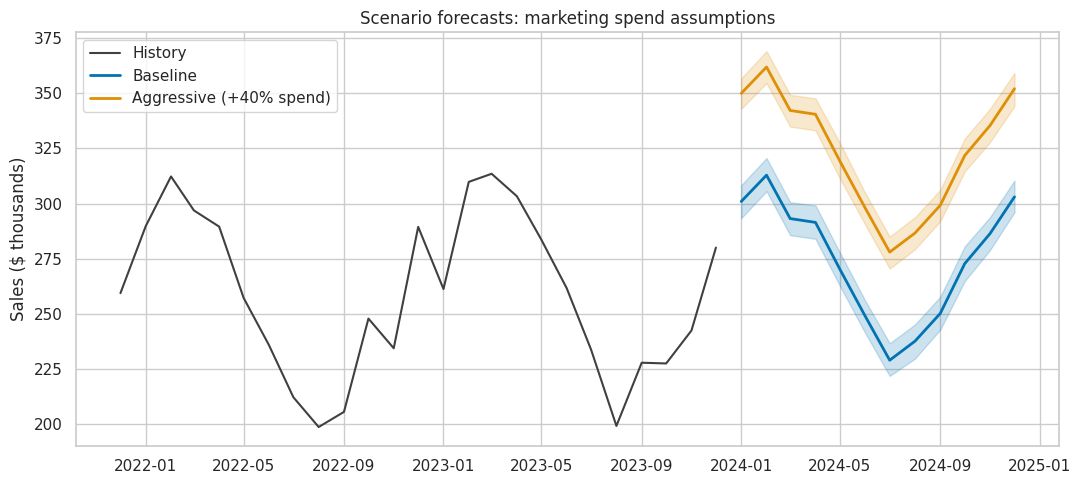

In [23]:
def plot_scenarios(
    history: pd.DataFrame,
    scenarios: dict[str, pd.DataFrame],
    *,
    history_years: int = 2,
) -> plt.Figure:
    """Overlay history and named scenario forecasts with uncertainty bands."""
    cutoff = history["ds"].max() - pd.DateOffset(years=history_years)
    hist_window = history.loc[history["ds"] >= cutoff]

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.lineplot(
        data=hist_window,
        x="ds",
        y="y",
        ax=ax,
        color="0.25",
        linewidth=1.5,
        label="History",
    )

    palette = sns.color_palette("colorblind", n_colors=len(scenarios))
    for (name, forecast), color in zip(scenarios.items(), palette):
        future_only = forecast.loc[forecast["ds"] > history["ds"].max()]
        sns.lineplot(
            data=future_only,
            x="ds",
            y="yhat",
            ax=ax,
            color=color,
            linewidth=2,
            label=name,
        )
        ax.fill_between(
            future_only["ds"],
            future_only["yhat_lower"],
            future_only["yhat_upper"],
            color=color,
            alpha=0.2,
        )

    ax.set(
        title="Scenario forecasts: marketing spend assumptions",
        xlabel="",
        ylabel="Sales ($ thousands)",
    )
    ax.legend()
    fig.tight_layout()
    return fig


plot_scenarios(
    history=df,
    scenarios={
        "Baseline": fc_baseline,
        "Aggressive (+40% spend)": fc_aggressive,
    },
);

### Report projected totals

Decision-makers often want a single number per scenario: total projected sales over the horizon, with an uncertainty range.

In [24]:
def scenario_summary(
    scenarios: dict[str, pd.DataFrame],
    history: pd.DataFrame,
) -> pd.DataFrame:
    """Sum projected sales over the forecast horizon for each scenario."""
    last_hist = history["ds"].max()
    rows = []
    for name, forecast in scenarios.items():
        future_only = forecast.loc[forecast["ds"] > last_hist]
        rows.append(
            {
                "scenario": name,
                "projected_total": future_only["yhat"].sum(),
                "lower": future_only["yhat_lower"].sum(),
                "upper": future_only["yhat_upper"].sum(),
            }
        )
    summary = pd.DataFrame(rows)
    # Round for a clean report table.
    for col in ["projected_total", "lower", "upper"]:
        summary[col] = summary[col].round(1)
    return summary


summary = scenario_summary(
    scenarios={
        "Baseline": fc_baseline,
        "Aggressive (+40% spend)": fc_aggressive,
    },
    history=df,
)
summary

,scenario,projected_total,lower,upper
0,Baseline,3296.4,3206.6,3386.8
1,Aggressive (+40% spend),3885.2,3796.2,3972.3


## Your turn: construct and report scenarios

Use `forecast_scenario` and `scenario_summary` (and optionally `plot_scenarios`) to build three new plans and report their projected forecasts.

**Suggested scenarios** (pick these or invent your own):

1. **Conservative** — cut spend 25% relative to Baseline every month.
2. **Holiday campaign** — keep Baseline spend, then double it in November and December only.
3. **Gradual ramp** — start at Baseline and increase spend linearly to +50% by month 12.

For each scenario, produce:

- the 12-month `yhat` path (or an overlay plot); and
- a summary row with projected total + lower/upper bounds.

In [25]:
# TODO 1: build future_spend arrays for your three scenarios.
# Hint: start from `baseline_spend` defined above.

conservative_spend = ...  # e.g. baseline_spend * 0.75

holiday_spend = ...  # copy baseline, then boost months 10 and 11 (0-indexed Nov/Dec if horizon starts in Jan)

ramp_spend = ...  # linear from 1.0x to 1.5x baseline

your_scenarios_spend = {
    "Conservative (−25%)": conservative_spend,
    "Holiday campaign": holiday_spend,
    "Gradual ramp": ramp_spend,
}

In [26]:
# TODO 2: forecast each scenario and collect them in a dict.

your_forecasts = {}
for name, spend in your_scenarios_spend.items():
    # your_forecasts[name] = forecast_scenario(model=m, future_spend=spend)
    pass

your_forecasts


{}

In [27]:
# TODO 3: report projected totals with uncertainty.

# your_summary = scenario_summary(scenarios=your_forecasts, history=df)
# your_summary

In [28]:
# TODO 4 (optional): overlay your scenarios on the history.

# plot_scenarios(history=df, scenarios=your_forecasts);

### Stretch: two drivers at once

The CSV also includes `avg_price`. Refit a model with **both** `marketing_spend` and `avg_price` as regressors, then invent a combined scenario (e.g. higher spend **and** a temporary price cut) and compare it to Baseline.

Remember: every future row needs **both** regressor columns filled before you call `predict`.

In [29]:
# TODO 5 (stretch): fit a two-regressor model and compare a combined scenario.
#
# m2 = Prophet(weekly_seasonality=False, yearly_seasonality=True)
# m2.add_regressor("marketing_spend")
# m2.add_regressor("avg_price")
# m2.fit(df)
# ... build future frames with both columns, predict, summarise ...

## Takeaways

- Extra regressors require **future values**. When those values are assumptions, you are doing scenario-based forecasting.
- Build scenarios that decision-makers recognise (budget cut, campaign spike, gradual ramp), not arbitrary noise.
- Always report **point forecasts and uncertainty intervals** per scenario — scenarios answer "what if?", intervals answer "how sure?".